# Model Training — interactive walkthrough

Phase 0 of `todo-model-training.md`, made runnable. This notebook does
the *real* thing end to end against the live warehouse — no mock data,
no fabricated metrics. Every number you see below is either queried
from Postgres or computed from a real training run.

**What this notebook does, in order:**
1. Loads real demand data from the warehouse and checks, per region,
   whether it actually has everything a model needs (this matters —
   see step 1b, a real gap this project hit).
2. Finds the longest *fully complete* contiguous window of data for
   whichever region you pick, and recommends a `lookback`/`horizon`
   that actually fits what's currently in the warehouse (rather than
   assuming the model's textbook defaults apply).
3. Trains the real `DemandLSTM` (`app/models/ml.py`) on that window.
4. Trains a real seasonal-naive baseline (`app/models/baseline.py`,
   built alongside this notebook) to compare against — a model is
   only useful if it beats the dumb-but-honest baseline.
5. Plots both, and gives you an optional cell to register the run to
   MLflow if you're happy with it.

**Kernel:** run `uv run python -m ipykernel install --user --name
ecolens-data-pipeline` from `services/data-pipeline` first (already
done once as part of setting this notebook up), then select
**"ecoLens (data-pipeline)"** as this notebook's kernel — it needs
`services/data-pipeline`'s venv (torch, mlflow, sqlalchemy, ...), not
your base Python.

**Before running:** a real Postgres warehouse and a real MLflow
server both need to be reachable — check `services/data-pipeline/.env`
has a working `DATABASE_URL` and `MLFLOW_TRACKING_URI`. If you don't
have an MLflow server running, everything up through the plots still
works — only the last (optional) registration cell needs it.

Questions as you go: just ask, in-line or at the end — there's a
"Questions" cell at the bottom to jot things down, or ask me directly.

## Setup

In [1]:
import sys
import os
from pathlib import Path
from dotenv import dotenv_values

# This notebook can live at `<repo>/notebooks/` or (as moved) at
# `<repo>/services/data-pipeline/notebooks/` -- search a few likely
# spots, then walk upward, instead of assuming a fixed relative offset.
# Whichever kernel/cwd this runs under, print exactly what we found so
# there's no ambiguity if something still looks wrong.
def _find_data_pipeline_dir() -> Path:
    marker = Path("app") / "core" / "config.py"
    candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd() / "services" / "data-pipeline",
        Path.cwd().parent / "services" / "data-pipeline",
    ]
    for candidate in candidates:
        candidate = candidate.resolve()
        if (candidate / marker).exists():
            return candidate
    cur = Path.cwd().resolve()
    for _ in range(8):
        candidate = (cur / "services" / "data-pipeline").resolve()
        if (candidate / marker).exists():
            return candidate
        if cur.parent == cur:
            break
        cur = cur.parent
    raise FileNotFoundError(
        f"couldn't locate services/data-pipeline (with app/core/config.py) "
        f"starting from cwd={Path.cwd()}"
    )

DATA_PIPELINE_DIR = _find_data_pipeline_dir()
sys.path.insert(0, str(DATA_PIPELINE_DIR))
os.chdir(DATA_PIPELINE_DIR)

# Read .env by absolute path and inject straight into os.environ --
# immune to cwd/caching/import-order issues (pydantic-settings'
# env_file=".env" is cwd-relative at Settings() instantiation time,
# which has bitten this notebook twice already).
env_path = DATA_PIPELINE_DIR / ".env"
assert env_path.exists(), f"no .env at {env_path}"
for key, value in dotenv_values(env_path).items():
    if value is not None:
        os.environ[key] = value

try:
    from app.core.config import get_settings
    get_settings.cache_clear()
except ImportError:
    pass

print("python:", sys.executable)
print("resolved services/data-pipeline at:", DATA_PIPELINE_DIR)
print("cwd:", Path.cwd())
print("loaded .env from:", env_path)


python: /Users/macbook/Project/research/EcoLens/.venv/bin/python3
resolved services/data-pipeline at: /Users/macbook/Project/research/EcoLens/services/data-pipeline
cwd: /Users/macbook/Project/research/EcoLens/services/data-pipeline
loaded .env from: /Users/macbook/Project/research/EcoLens/services/data-pipeline/.env


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from app.core.config import get_settings
from app.db.session import get_session
from app.models.baseline import seasonal_naive_forecast
from app.service.ml.data import load_holidays, load_training_data, split_by_time
from app.service.ml.features import NUMERIC_COLUMNS, TARGET_COLUMN, build_features
from app.service.ml.train import TrainConfig, log_and_register_run, train_model
from app.service.mlops.tracking import configure_mlflow

settings = get_settings()

# Sanity check the real config this notebook is about to use -- masked,
# since DATABASE_URL has real credentials in it. Fail loudly here
# rather than deep inside a query if the wrong .env got picked up.
db_host = settings.database_url.split("@")[-1].split("/")[0]
assert "ep-noisy-water" in db_host, (
    f"Connected to the WRONG database ({db_host}) -- this one doesn't have "
    "raw_marts.fct_energy_demand. Restart the kernel and re-run from the "
    "Setup cell; if this still fails, your editor may be running a stale "
    "in-memory copy of this notebook instead of what's on disk."
)
print("DATABASE_URL host:", db_host)
print("MLFLOW_TRACKING_URI:", settings.mlflow_tracking_uri)
print("registered model name:", settings.mlflow_registry_model_name)

configure_mlflow(settings)
print("mlflow experiment configured OK")


DATABASE_URL host: ep-noisy-water-azxkg7c7-pooler.c-3.ap-southeast-1.aws.neon.tech
MLFLOW_TRACKING_URI: http://localhost:5001
registered model name: lstm_demand
mlflow experiment configured OK


## 1. What's actually in the warehouse right now

`ml/data.py`'s `load_training_data` reads `raw_marts.fct_energy_demand`
— one row per `(ts, region)`, with `demand_mw`/`price_mwh` from AEMO
dispatch, `total_generation_mw`/`total_renewable_mw` from
OpenElectricity, and weather from BoM, all joined together by dbt.

**Real gap this project hit (fixed, but worth understanding):** demand
and generation-mix are reported by *different* real-world feeds that
don't cover the same regions or timestamps. `NSW1`/`QLD1`/`VIC1`/`SA1`/
`TAS1` (the individual NEM regions) have real demand but *no*
generation-mix data — OpenElectricity only reports at the whole-NEM
level. Only the `NEM` (aggregate) and `WEM` pseudo-regions have both.
Run the cell below yourself to see the current real numbers — this
will change as more data gets ingested, so don't trust a stale comment
over what this actually prints.

In [3]:
ALL_REGIONS = ["NSW1", "QLD1", "VIC1", "SA1", "TAS1", "WEM", "NEM"]

async with get_session() as db:
    raw_all = await load_training_data(db, ALL_REGIONS)

region_summary = raw_all.groupby("region").agg(
    rows=("ts", "count"),
    min_ts=("ts", "min"),
    max_ts=("ts", "max"),
    demand_non_null=("demand_mw", lambda s: s.notna().sum()),
    generation_non_null=("total_generation_mw", lambda s: s.notna().sum()),
)
region_summary["has_both"] = (region_summary["demand_non_null"] > 0) & (
    region_summary["generation_non_null"] > 0
)
region_summary

,rows,min_ts,max_ts,demand_non_null,generation_non_null,has_both
region,,,,,,
NEM,8475,2026-06-27 17:50:00+00:00,2026-07-27 04:00:00+00:00,0,8475,False
NSW1,9281,2026-03-31 14:30:00+00:00,2026-08-03 18:05:00+00:00,9281,0,False
QLD1,9281,2026-03-31 14:30:00+00:00,2026-08-03 18:05:00+00:00,9281,0,False
SA1,9281,2026-03-31 14:30:00+00:00,2026-08-03 18:05:00+00:00,9281,0,False
TAS1,9281,2026-03-31 14:30:00+00:00,2026-08-03 18:05:00+00:00,9281,0,False
VIC1,9281,2026-03-31 14:30:00+00:00,2026-08-03 18:05:00+00:00,9281,0,False
WEM,9148,2026-04-01 00:00:00+00:00,2026-08-03 18:00:00+00:00,8860,8716,True


## 2. Pick a region, then find its real usable window

Even a region with "both" columns present isn't automatically ready to
train on: `demand_mw`/`total_generation_mw`/weather are three
independently-sampled real feeds, and a model needs `lookback+horizon`
**consecutive** rows where *all* of `FEATURE_COLUMNS` are non-null —
not just "some rows somewhere have every column filled in". The cell
below finds the longest such contiguous run and recommends a
`lookback`/`horizon` that actually fits it, instead of assuming the
model's textbook default (48/48 — 24h at 5-min resolution) works.

**Change `REGION` here and re-run everything below** to explore a
different region — pick one that showed `has_both = True` above.

In [4]:
REGION = "WEM"  # <- change me and re-run from here down


def longest_complete_run(df: pd.DataFrame, columns) -> tuple[int, pd.Timestamp | None, pd.Timestamp | None]:
    """Longest run of consecutive rows (by position, `df` must already be
    sorted by ts) where every column in `columns` is non-null. Returns
    (length, window_start_ts, window_end_ts) -- (0, None, None) if there's
    no complete row at all."""
    mask = df[list(columns)].notna().all(axis=1).to_numpy()
    best_len = best_start = cur_start = cur_len = 0
    for i, ok in enumerate(mask):
        if ok:
            if cur_len == 0:
                cur_start = i
            cur_len += 1
            if cur_len > best_len:
                best_len, best_start = cur_len, cur_start
        else:
            cur_len = 0
    if best_len == 0:
        return 0, None, None
    return best_len, df.iloc[best_start]["ts"], df.iloc[best_start + best_len - 1]["ts"]


async with get_session() as db:
    raw_region = await load_training_data(db, [REGION])

feats_full = build_features(raw_region).sort_values("ts").reset_index(drop=True)
run_len, run_start, run_end = longest_complete_run(feats_full, NUMERIC_COLUMNS)

print(f"{REGION}: {len(feats_full)} rows total")
print(f"longest fully-complete contiguous run: {run_len} rows")
if run_start is not None:
    print(f"  window: {run_start} -> {run_end}")
    median_step_s = feats_full["ts"].diff().dt.total_seconds().dropna().median()
    steps_per_day = round(86400 / median_step_s) if median_step_s else None
    print(f"  median step: {median_step_s:.0f}s (~{steps_per_day} steps/day)")
    # Rough starting point, not a guarantee: after a 70/15/15 time split,
    # the *smallest* split needs to clear lookback+horizon on its own.
    # If training still fails with "not enough history", shrink further --
    # this is a heuristic, not an exact bound (cal_frac splits val again).
    # Heuristic, not an exact bound: after a 70/15/15 time split, train_model
    # further splits the 15% "val" portion into earlystop_val/calibration
    # (cal_frac=0.5 by default), so the truly smallest slice is
    # ~0.15 * 0.5 * (a safety margin) of the total, not 0.15 outright.
    recommended = max(1, int(run_len * 0.0225))
    print(f"  starting-point recommendation: lookback = horizon <= ~{recommended} steps")
else:
    print("No fully-complete window at all for this region right now -- try a different REGION.")

WEM: 9148 rows total
longest fully-complete contiguous run: 278 rows
  window: 2026-07-27 06:00:00+00:00 -> 2026-08-03 18:00:00+00:00
  median step: 300s (~288 steps/day)
  starting-point recommendation: lookback = horizon <= ~6 steps


## 3. Load just the dense window, and split it

Re-queries with `since=` set to the dense window's start (matches how
the real training pipeline was actually run this project so far) —
note this does cost a few rows of lag/rolling "warmup" at the very
start of the window (those features need prior rows that are now
outside the query), which is why the usable row count below is a
little less than `run_len` above.

In [5]:
LOOKBACK = recommended  # edit directly if you want to try something else
HORIZON = recommended

async with get_session() as db:
    raw_df = await load_training_data(db, [REGION], since=run_start)
    holidays_df = await load_holidays(db)

print(f"rows loaded for training: {len(raw_df)}")

# Sanity-check each split *before* training, so a "not enough history"
# error (if it happens) is explained here rather than raised deep
# inside train_model.
feats_check = build_features(raw_df).sort_values("ts").reset_index(drop=True)
split_check = split_by_time(feats_check, train_frac=0.7, val_frac=0.15)
for name, part in [("train", split_check.train), ("val", split_check.val), ("test", split_check.test)]:
    part = part.reset_index(drop=True)
    run_len_part, *_ = longest_complete_run(part, NUMERIC_COLUMNS)
    ok = "OK" if run_len_part >= LOOKBACK + HORIZON else "TOO SHORT"
    print(f"{name}: {len(part)} rows, longest complete run {run_len_part} (need >= {LOOKBACK + HORIZON}) [{ok}]")

rows loaded for training: 278
train: 194 rows, longest complete run 182 (need >= 12) [OK]
val: 42 rows, longest complete run 42 (need >= 12) [OK]
test: 42 rows, longest complete run 42 (need >= 12) [OK]


If any split above says `TOO SHORT`, lower `LOOKBACK`/`HORIZON` in the
cell above and re-run this cell before continuing — training will
raise the same real `ValueError` `ecolens-pipeline train` did this
session if you skip ahead anyway, so it's better to catch it here.

## 4. Baseline: seasonal-naive

`app/models/baseline.py`'s `seasonal_naive_forecast` — real historical
quantiles, no training. With only a handful of days of dense data
available right now, a *weekly* seasonal period isn't achievable (it'd
need multiple weeks of history just for `n_periods=1`), so this uses a
*daily* period instead — pick whichever real period your data
actually supports, don't force weekly just because that's the more
"standard" choice for demand data.

In [6]:
# Use the dense WINDOW's own real cadence, not the full raw region series' -- outside the dense window rows can be sparser, which previously made period_steps too large for this window (every baseline forecast came back NaN).
window_step_s = feats_check["ts"].diff().dt.total_seconds().dropna().median()
window_steps_per_day = round(86400 / window_step_s) if window_step_s else steps_per_day
print(f"real cadence inside the dense window: {window_step_s:.0f}s (~{window_steps_per_day} steps/day)")
period_steps = window_steps_per_day  # daily seasonality -- see markdown above for why not weekly
n_periods = max(2, min(8, len(split_check.train) // period_steps))

test_df = split_check.test.reset_index(drop=True)
history_for_baseline = pd.concat([split_check.train, split_check.val], ignore_index=True)[TARGET_COLUMN]

# Walk-forward: forecast HORIZON steps from a handful of origins spread
# across the test split, score each against what actually happened.
n_origins = min(10, max(1, len(test_df) - HORIZON))
origins = np.linspace(0, len(test_df) - HORIZON - 1, n_origins, dtype=int) if len(test_df) > HORIZON else []

baseline_errors = []
for origin in origins:
    history = pd.concat(
        [history_for_baseline, test_df[TARGET_COLUMN].iloc[:origin]], ignore_index=True
    )
    forecast = seasonal_naive_forecast(history, horizon=HORIZON, period_steps=period_steps, n_periods=n_periods)
    actual = test_df[TARGET_COLUMN].iloc[origin : origin + HORIZON].to_numpy()
    pred = forecast["p50"].to_numpy()
    valid = ~np.isnan(pred) & (actual != 0)
    if valid.any():
        baseline_errors.append(np.mean(np.abs((actual[valid] - pred[valid]) / actual[valid])) * 100)

baseline_mape = float(np.mean(baseline_errors)) if baseline_errors else float("nan")
print(f"seasonal-naive baseline MAPE over {len(baseline_errors)} origins: {baseline_mape:.2f}%")

real cadence inside the dense window: 1800s (~48 steps/day)
seasonal-naive baseline MAPE over 10 origins: 6.55%


## 5. Train the real LSTM

Same `TrainConfig`/`train_model` the real `ecolens-pipeline train` CLI
and `POST /v1/model/train`'s worker path use — nothing notebook-special
about this, it's the actual production training function. Epochs kept
low by default so this runs in seconds on a laptop CPU; raise it once
you're happy with the setup.

In [7]:
config = TrainConfig(
    lookback=LOOKBACK,
    horizon=HORIZON,
    epochs=15,
    batch_size=16,
    early_stopping_patience=5,
)

result = train_model(raw_df, config, holidays=holidays_df)
print("\ntest_metrics:", result.test_metrics)
print("train/val/cal/test windows:", result.n_train_windows, result.n_val_windows, result.n_cal_windows, result.n_test_windows)

{"epoch": 0, "train_loss": 0.8447675759142096, "val_mape": 8.219047546386719, "event": "train.epoch", "level": "info", "timestamp": "2026-08-04T07:37:48.552569Z"}


{"epoch": 1, "train_loss": 0.6196974813938141, "val_mape": 10.177423477172852, "event": "train.epoch", "level": "info", "timestamp": "2026-08-04T07:37:48.624973Z"}


{"epoch": 2, "train_loss": 0.3972535783594305, "val_mape": 15.410529136657715, "event": "train.epoch", "level": "info", "timestamp": "2026-08-04T07:37:48.682571Z"}


{"epoch": 3, "train_loss": 0.3061454377391122, "val_mape": 12.191896438598633, "event": "train.epoch", "level": "info", "timestamp": "2026-08-04T07:37:48.766571Z"}


{"epoch": 4, "train_loss": 0.24942024052143097, "val_mape": 12.529565811157227, "event": "train.epoch", "level": "info", "timestamp": "2026-08-04T07:37:48.847793Z"}


{"epoch": 5, "train_loss": 0.24156039140441202, "val_mape": 13.174542427062988, "event": "train.epoch", "level": "info", "timestamp": "2026-08-04T07:37:48.906654Z"}


{"epoch": 5, "best_val_mape": 8.219047546386719, "event": "train.early_stop", "level": "info", "timestamp": "2026-08-04T07:37:48.907059Z"}



test_metrics: {'test_mape': 11.229387283325195, 'test_coverage_raw': 0.6451612903225806, 'test_coverage_calibrated': 0.989247311827957}
train/val/cal/test windows: 171 10 10 31


## 6. Compare: LSTM vs. baseline

The whole point of Phase 0 (`todo-model-training.md`) building a real
baseline: a trained model that doesn't clearly beat seasonal-naive on
*this* data isn't earning its complexity yet. Look at this honestly —
with only a handful of days of dense training data, don't be surprised
if the LSTM doesn't win by much (or at all) right now; that's a real,
reportable result, not a notebook bug.

In [8]:
lstm_mape = result.test_metrics.get("test_mape", float("nan"))
print(f"LSTM   test_mape: {lstm_mape:.2f}%")
print(f"Naive  test_mape: {baseline_mape:.2f}%")
if lstm_mape < baseline_mape:
    print(f"LSTM beats the baseline by {baseline_mape - lstm_mape:.2f} points.")
else:
    print(f"LSTM does NOT beat the baseline right now (behind by {lstm_mape - baseline_mape:.2f} points) -- real result, worth digging into (more data? more epochs? different lookback/horizon?).")

LSTM   test_mape: 11.23%
Naive  test_mape: 6.55%
LSTM does NOT beat the baseline right now (behind by 4.68 points) -- real result, worth digging into (more data? more epochs? different lookback/horizon?).


## 7. Visualize

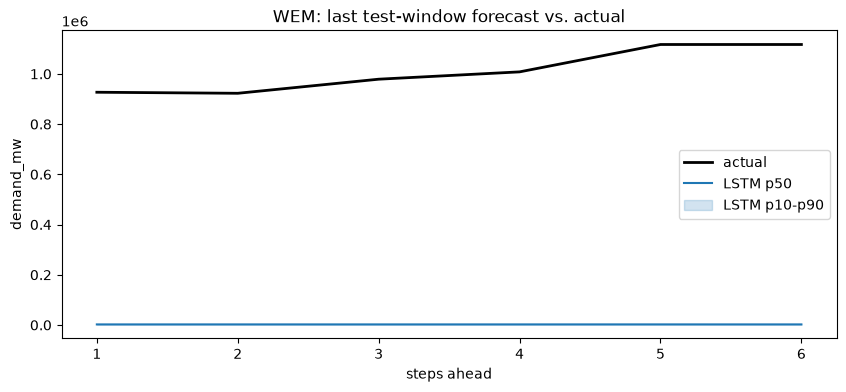

In [9]:
# Re-run inference once more on the last test-split window purely for
# plotting -- train_model already did this internally for test_metrics,
# but doesn't hand back the raw per-step predictions.
import torch

from app.service.ml.data import DemandDataset, apply_scalers

device = torch.device("cpu")
result.model.eval()

test_scaled = apply_scalers(split_check.test, result.feature_scalers)
test_ds = DemandDataset(test_scaled, lookback=LOOKBACK, horizon=HORIZON, target_col=TARGET_COLUMN)

if len(test_ds) > 0:
    x, y_true_scaled = test_ds[len(test_ds) - 1]
    with torch.no_grad():
        out = result.model(x.unsqueeze(0).to(device))

    def _inverse(t):
        return result.target_scaler.inverse_transform(t.numpy().reshape(-1, 1)).reshape(-1)

    p10, p50, p90 = _inverse(out.p10[0]), _inverse(out.p50[0]), _inverse(out.p90[0])
    y_true = _inverse(y_true_scaled)

    fig, ax = plt.subplots(figsize=(10, 4))
    steps = range(1, HORIZON + 1)
    ax.plot(steps, y_true, label="actual", color="black", linewidth=2)
    ax.plot(steps, p50, label="LSTM p50", color="tab:blue")
    ax.fill_between(steps, p10, p90, color="tab:blue", alpha=0.2, label="LSTM p10-p90")
    ax.set_xlabel("steps ahead")
    ax.set_ylabel("demand_mw")
    ax.set_title(f"{REGION}: last test-window forecast vs. actual")
    ax.legend()
    plt.show()
else:
    print("Test split too short to plot a full window -- reduce LOOKBACK/HORIZON and re-run from section 3.")

## 8. (Optional) Register this run to MLflow

Set `REGISTER = True` and run this cell only if you actually want this
run to become a real MLflow-tracked version. It lands at whatever
stage MLflow assigns new registrations (`None`/unassigned) — promoting
to Production is a separate, deliberately-gated step (`promote_version`
in forecast-api, or `POST /v1/model/versions/{version}/promote`), not
automatic here.

In [10]:
REGISTER = False

if REGISTER:
    reg_result = log_and_register_run(
        result, config, [REGION], settings.mlflow_registry_model_name, register=True
    )
    print("run_id:", reg_result.run_id)
    print("model_version:", reg_result.model_version)
else:
    print("REGISTER is False -- nothing logged. Set REGISTER = True above to actually register this run.")

REGISTER is False -- nothing logged. Set REGISTER = True above to actually register this run.


## Next steps

This is Phase 0 of `todo-model-training.md` — a real baseline, a real
evaluation-by-hand of the existing LSTM, on whatever data is actually
in the warehouse right now. Phases 1-2 (TimesFM, then a Temporal
Fusion Transformer) add more real experts to compare the same way;
Phase 3 blends them. None of that is built yet — this notebook is the
"can I see and trust what exists today" step before any of it starts.

Things worth trying yourself:
- Change `REGION` in section 2 and re-run — does a different region's
  dense window give a meaningfully different result?
- Raise `epochs` in section 5 now that you've seen it run once fast.
- Come back and re-run this whole notebook after more real data has
  been ingested (backfills, more days passing) — the dense-window
  diagnostic in section 2 will pick up more history automatically and
  should let `LOOKBACK`/`HORIZON` grow toward the model's real
  defaults (48/48) as more days of complete data accumulate.

## Questions

(jot anything down here as you go — or just ask directly)